# Imports & Initializations

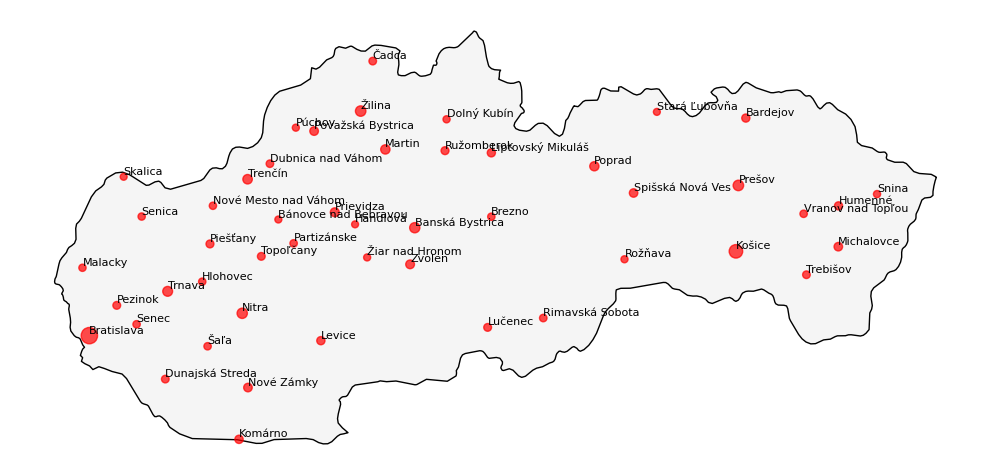

,City,Longitude,Latitude,Population,Weight,geometry
0,Bratislava,17.107362,48.147722,479389,0.221086,POINT (-573721.533 -1280416.687)
1,Košice,21.250169,48.716782,223678,0.103157,POINT (-263382.1 -1239958.625)
2,Prešov,21.246051,49.001436,81702,0.037680,POINT (-262204.075 -1208325.891)
3,Žilina,18.736655,49.218791,80257,0.037013,POINT (-443503.915 -1172635.637)
4,Nitra,18.076839,48.306085,75945,0.035025,POINT (-500350.884 -1269696.866)
5,Banská Bystrica,19.149165,48.734752,73533,0.033912,POINT (-417535.52 -1228621.98)
6,Trnava,17.583100,48.371006,63180,0.029138,POINT (-536139.616 -1259161.756)
7,Trenčín,18.034399,48.884555,54130,0.024964,POINT (-497777.189 -1205350.404)
8,Martin,18.918379,49.062108,50346,0.023219,POINT (-431651.775 -1191044.865)
9,Poprad,20.295367,49.051114,48352,0.022299,POINT (-331335.948 -1199126.177)


In [28]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt


DF_MESTA = pd.read_csv(
    'data/slovensko.csv',
    sep=','
)

SUCET_POPULACIE = DF_MESTA['Population'].sum()
DF_MESTA['Weight'] = DF_MESTA['Population'] / SUCET_POPULACIE

DF_MESTA['geometry'] = [Point(xy) for xy in zip(DF_MESTA['Longitude'], DF_MESTA['Latitude'])]

DF_MESTA = gpd.GeoDataFrame(DF_MESTA, geometry='geometry', crs='EPSG:4326')
DF_MESTA = DF_MESTA.to_crs(epsg=5514)

# world = gpd.read_file(
#     "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
# )
# slovakia = world[world["ADMIN"] == "Slovakia"]
# slovakia = gpd.read_file(
#     "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_SVK_0.json"
# )
slovakia = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)

slovakia = slovakia[slovakia["ISO_A3"] == "SVK"]
slovakia = slovakia.to_crs(epsg=5514)


fig, ax = plt.subplots(figsize=(10,8))

slovakia.plot(
    ax=ax,
    color='whitesmoke',
    edgecolor='black'
)

DF_MESTA.plot(
    ax=ax,
    color='red',
    markersize=np.sqrt(DF_MESTA['Population']) / 5,
    alpha=0.7
)

for x,y,city in zip(DF_MESTA.geometry.x, DF_MESTA.geometry.y, DF_MESTA['City']):
    ax.text(x,y,city, fontsize=8, ha='left', va='bottom')

ax.set_axis_off()

plt.tight_layout()
plt.show()


display(DF_MESTA)

In [19]:
# print(world.columns)
# print(world[["ADMIN", "NAME", "SOVEREIGNT"]].head())
# print(world[world.astype(str).apply(lambda row: row.str.contains("Slovak", case=False).any(), axis=1)])
minx, miny, maxx, maxy = slovakia.total_bounds
print(minx, miny, maxx, maxy)

16.879982944413 47.75842886005037 22.558137648211755 49.571574001659194


# Uloha a)



Mame funkciu
$$
f(x) = \sum_{i=1}^m w_i \|x-a^i\|_2
$$

kde $m$ je pocet miest, $w_i$ je vaha pridelena $i$-temu mestu a $a^i$ su 2d suradnice $i$-teho miesta 
***
Oznacme si
$$
\begin{aligned}
u_i &= x_1 - a_1^i \\
v_i &= x_2 - a_2^i \\
d_i(x) &= \sqrt{u_i^2 + v_i^2} = \|x-a^i\|_2
\end{aligned}
$$

Gradient tejto funkcie
$$

\nabla f(x) = 
\begin{pmatrix}
\displaystyle \sum_{i=1}^m w_i \frac{u_i}{d_i(x)} \\
\displaystyle \sum_{i=1}^m w_i \frac{v_i}{d_i(x)}
\end{pmatrix}
$$
V kompaktnej forme
$$
\nabla f(x) = \displaystyle \sum_{i=1}^m w_i \frac{x-a^i}{\|x-a^i\|_2}
$$

Hesseho matica
$$
\nabla^2 f(x) = 
\displaystyle \sum_{i=1}^m w_i
\begin{pmatrix}
\frac{1}{d_i} - \frac{u_i^2}{d_i^3} & -\frac{u_iv_i}{d_i^3} \\
-\frac{u_iv_i}{d_i^3} & \frac{1}{d_i} - \frac{v_i^2}{d_i^3}
\end{pmatrix}
$$

V kompaktnej forme:
$$
\nabla^2 f(x) = \displaystyle \sum_{i=1}^m w_i \left[ \frac{1}{\|x-a^i\|_2}I - \frac{(x-a^i)(x-a^i)^\top}{\|x-a^i\|^3_2} \right]
$$

# Uloha b)

**Globalne minimum existuje**: Majme hodnoty 
$$
a = min(a_1^i) \forall i \\
b = max(a_1^i) \forall i \\
c = min(a_2^i) \forall i \\
d = max(a_2^i) \forall i 
$$

Potom z tychto bodov vytvorme obdlznik s vrcholmi 
$$
[a,c], [a,d], [b,c], [b,d]
$$

Ak mame bod mimo tochto obdlznika, urcite to nebude minimum funkcie, lebo sa mozeme posunut, k najblizsiemu bodu na hrane tochto obdlznika, cim hodnotu funkcie znizime. Tym padom, ak globalne minimum existuje, musi sa nachadzat v tomto obdlzniku. 

Tento obdlznik je uzavrety a funkcia je spojita, preto mozeme pouzit Weierstrassovu vetu o extreme, ktora hovori, ze v tejto oblasti funkcia nadobudne minimum, a toto bude aj nase hladane globalne minimum.


**Riesenie nie je vo vseobecnosti jednoznacne**. Uvazujume priklad, v ktorom mame 2 mesta s rovnakym poctom obyvatelov. V takom pripade mame rovnaku hodnotu funkcie na celej usecke medzi tymito bodmi.

# Uloha c)

$$
\nabla f(x) = \displaystyle \sum_{i=1}^m w_i \frac{x-a^i}{\|x-a^i\|_2} = 0
$$



$$
\displaystyle \sum_{i=1}^m w_i \frac{x}{\|x-a^i\|_2} 
- \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2} = 0
$$

$$
\displaystyle \sum_{i=1}^m w_i \frac{x}{\|x-a^i\|_2} = \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2}
$$

$$
\left( \displaystyle \sum_{i=1}^m \frac{w_i}{\|x-a^i\|_2} \right) x = \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2}
$$

$$
x = \frac{\displaystyle \sum_{i=1}^m \frac{w_i a^i}{\|x-a^i\|_2}}{\displaystyle \sum_{i=1}^m \frac{w_i}{\|x-a^i\|_2}}
$$

# Uloha d)

In [ ]:
x0 = 